# Synthetic Data Experiment - Refactored

This notebook evaluates metabolic flux prediction methods on synthetic data with controlled noise levels and missing values.

## Imports

In [1]:
print("test")

test


In [2]:
import os
import sys
import hashlib
import json
import cobra
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import seaborn as sns
import math
import torch
import scipy
import scipy.stats as stats
import scipy.linalg
from projection_methods import MoMAWrapper, FBApro, FBAWrapper, IMATWrapper
import util

In [3]:
# os.environ['GRB_LICENSE_FILE'] = "../argo_comp1_grb_key/gurobi.lic"

In [4]:
# Canonical method order used throughout all figures
METHOD_ORDER = ["FBAproBasic", "FBAproPartial", "FBAproFixed", "FBAproFull",
                "FBA", "MoMA", "iMAT"]

def normalize_method_name(name):
    """Normalize method names from internal naming to canonical display names."""
    name = name.replace("LowMid", "Partial").replace("HighMid", "Fixed")
    if name == "FBApro":
        return "FBAproBasic"
    if name == "FBAproPartialFixed":
        return "FBAproFull"
    return name

def set_method_order(df, col='method'):
    """Set canonical categorical ordering on the method column."""
    present = [m for m in METHOD_ORDER if m in df[col].unique()]
    df[col] = pd.Categorical(df[col], categories=present, ordered=True)
    return df

def get_reaction_directionality(model):
    """Identify bidirectional and unidirectional reactions."""
    bidirectional = [i for i, r in enumerate(model.reactions) 
                     if r.lower_bound < 0 and r.upper_bound > 0]
    unidirectional = [i for i in range(len(model.reactions)) 
                      if i not in bidirectional]
    return bidirectional, unidirectional

def generate_folder_name(params):
    """Generate legible folder name from parameters."""
    parts = []
    
    # Add model and sampling method
    if 'model' in params:
        parts.append(params['model'])
    if 'sampling_method' in params:
        samp_abbrev = {'basis': 'basis', 'cobrapy': 'cobra', 'random_fba': 'rfba'}
        parts.append(samp_abbrev.get(params['sampling_method'], params['sampling_method']))
    
    # Add experiment type
    if 'experiment_type' in params:
        parts.append(params['experiment_type'])
    
    # Add key numerical parameters with abbreviations
    if 'noise_power' in params and params['experiment_type'] == 'base':
        parts.append(f"n{params['noise_power']:.2f}")
    if 'frac_known' in params and params['experiment_type'] == 'base':
        parts.append(f"k{params['frac_known']:.3f}")
    if 'frac_unknown' in params and params['experiment_type'] == 'base':
        parts.append(f"u{params['frac_unknown']:.3f}")
    if 'bounds_epsilon' in params:
        parts.append(f"eps{params['bounds_epsilon']:.0e}".replace('e-0', 'e-'))
    if 'n_reaction_selections' in params:
        parts.append(f"rs{params['n_reaction_selections']}")
    if 'n_samples_per_selection' in params:
        parts.append(f"ns{params['n_samples_per_selection']}")
    
    return '_'.join(parts)

def save_parameters(params, output_dir):
    """Save parameters to text file."""
    os.makedirs(output_dir, exist_ok=True)
    param_file = os.path.join(output_dir, 'parameters.txt')
    with open(param_file, 'w') as f:
        for key, value in sorted(params.items()):
            f.write(f"{key}: {value}\n")

## Flux Sampling Methods

In [5]:
def generate_flux_samples(model, basis, n_samples, method='basis', device=None):
    """
    Generate synthetic flux samples using different methods.
    
    Args:
        model: cobra Model object
        basis: null space basis matrix (reactions × kernel_dim)
        n_samples: number of samples to generate
        method: 'basis', 'cobrapy', or 'random_fba'
        device: torch device (for consistency with other code)
    
    Returns:
        numpy array of shape (n_samples, n_reactions)
    """
    if method == 'basis':
        # Random coefficients on null space basis (current method)
        coefficients = np.random.random(size=(basis.shape[1], n_samples))
        steady_states = (basis @ coefficients).transpose()
        return steady_states
    
    elif method == 'cobrapy':
        # Use COBRApy's hit-and-run sampling
        try:
            samples = cobra.sampling.sample(model, n_samples, method='optgp')
            return samples.values  # Returns DataFrame, extract values
        except Exception as e:
            print(f"Warning: COBRApy sampling failed ({e}), falling back to basis sampling")
            coefficients = np.random.random(size=(basis.shape[1], n_samples))
            steady_states = (basis @ coefficients).transpose()
            return steady_states
    
    elif method == 'random_fba':
        # Solve FBA with random nonnegative objective coefficients
        samples = []
        with model:
            for i in range(n_samples):
                # Random nonnegative objective coefficients
                obj_coeffs = np.random.random(len(model.reactions))
                model.objective = {r: obj_coeffs[j] for j, r in enumerate(model.reactions)}
                
                try:
                    solution = model.optimize()
                    if solution.status == 'optimal':
                        samples.append(solution.fluxes.values)
                    else:
                        # If infeasible, use zeros
                        print(f"Warning: FBA sample {i} infeasible, using zeros")
                        samples.append(np.zeros(len(model.reactions)))
                except Exception as e:
                    print(f"Warning: FBA sample {i} failed, using zeros")
                    samples.append(np.zeros(len(model.reactions)))
        
        return np.array(samples)
    
    else:
        raise ValueError(f"Unknown sampling method: {method}")

## Configuration

**Modify these parameters to run different experiments**

In [6]:
# === EXPERIMENT CONFIGURATION ===
model_name = 'RECON1'  # 'RECON1' or 'Recon3D'
sampling_method = 'random_fba'  # 'basis', 'cobrapy', or 'random_fba'

# Multi-sampling parameters
n_reaction_samples_per_graph = 10  # Number of different reaction selections
n_samples_per_reaction_selection = 25  # Flux samples per selection

# Iterative experiments (smaller sample size)
iterative_n_reaction_samples = 5
iterative_n_samples_per_selection = 15

# Noise and masking parameters
base_noise_power = 1.0
base_frac_known_reactions = 0.02
base_frac_unknown_reactions = 0.85
bounds_epsilon = 1e-5  # Epsilon for bounds generation

# Varying ranges
noise_power_steps = list(np.linspace(start=0, stop=3, num=15, endpoint=True))
frac_known_steps = list(np.logspace(np.log10(0.01), np.log10(0.9), num=15))
frac_unknown_steps = list(np.logspace(np.log10(0.01), np.log10(0.9), num=15))


# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths
data_dir = 'synthetic_data_experiment_files/data'
caching_dir = 'synthetic_data_experiment_files/caching'
output_base_dir = 'synthetic_data_experiment_files/outputs'

print(f"Configuration:")
print(f"  Model: {model_name}")
print(f"  Sampling: {sampling_method}")
print(f"  Reaction selections: {n_reaction_samples_per_graph}")
print(f"  Samples per selection: {n_samples_per_reaction_selection}")
print(f"  Bounds epsilon: {bounds_epsilon}")
print(f"  Device: {device}")

Configuration:
  Model: RECON1
  Sampling: random_fba
  Reaction selections: 10
  Samples per selection: 25
  Bounds epsilon: 1e-05
  Device: cuda


## Load Model and Compute Basis

In [7]:
# Load single model
model_file = f"{model_name}.xml"
model = cobra.io.read_sbml_model(os.path.join(data_dir, model_file))

print(f"Loaded model: {model.id}")
print(f"  Reactions: {len(model.reactions)}")
print(f"  Metabolites: {len(model.metabolites)}")

# Load or compute stoichiometric matrix and null space basis
cache_A_path = os.path.join(caching_dir, f"{model_name}_cached_A.npy")
cache_basis_path = os.path.join(caching_dir, f"{model_name}_cached_basis.npy")

if os.path.exists(cache_A_path) and os.path.exists(cache_basis_path):
    print("Loading cached matrices...")
    A = np.load(cache_A_path)
    ss_basis = np.load(cache_basis_path)
else:
    print("Computing stoichiometric matrix and null space basis...")
    A = cobra.util.create_stoichiometric_matrix(model)
    ss_basis = scipy.linalg.null_space(A)
    os.makedirs(caching_dir, exist_ok=True)
    np.save(cache_A_path, A)
    np.save(cache_basis_path, ss_basis)

print(f"Stoichiometric matrix shape: {A.shape}")
print(f"Null space basis shape: {ss_basis.shape}")

# Get objective reaction
obj_coefs = {rxn.id: rxn.objective_coefficient for rxn in model.reactions 
             if rxn.objective_coefficient != 0}
if len(obj_coefs) == 0:
    growth_rxns = [r.id for r in model.reactions if 'biomass' in r.id.lower()]
    if len(growth_rxns) > 0:
        objective_reaction_id = growth_rxns[0]
    else:
        # Use first reaction as fallback
        objective_reaction_id = model.reactions[0].id
else:
    objective_reaction_id = list(obj_coefs.keys())[0]

print(f"Objective reaction: {objective_reaction_id}")

# Get reaction directionality
bidirectional_indices, unidirectional_indices = get_reaction_directionality(model)
print(f"Bidirectional reactions: {len(bidirectional_indices)}")
print(f"Unidirectional reactions: {len(unidirectional_indices)}")

Set parameter LicenseID to value 197246
Set parameter GURO_PAR_SPECIAL
Set parameter TokenServer to value "license.rc.princeton.edu"
Loaded model: RECON1
  Reactions: 3741
  Metabolites: 2766
Loading cached matrices...
Stoichiometric matrix shape: (2766, 3741)
Null space basis shape: (3741, 1067)
Objective reaction: S6T14g
Bidirectional reactions: 1549
Unidirectional reactions: 2192


## Data Generation and Method Execution

In [8]:
def run_complete_experiment(model, A, ss_basis, objective_id,
                           n_reaction_selections, n_samples_per_selection,
                           noise_power, frac_known, frac_unknown,
                           sampling_method='basis', device=torch.device('cuda'),
                           bounds_epsilon=1e-5, bidirectional_indices=None,
                           unidirectional_indices=None):
    """
    Run complete experiment: generate multiple reaction selections,
    generate samples, run methods, compute correlations.
    
    Args:
        bidirectional_indices: List of bidirectional reaction indices (optional)
        unidirectional_indices: List of unidirectional reaction indices (optional)

    Returns:
        results_df: DataFrame with correlation results (all reactions)
        results_bidir_df: DataFrame with correlation results (bidirectional reactions only)
        results_unidir_df: DataFrame with correlation results (unidirectional reactions only)
        violation_df: DataFrame with bound violation results
        timing_df: DataFrame with method timing results
    """
    import time
    
    n_rxns = A.shape[1]
    correlation_entries = []
    correlation_entries_bidir = []
    correlation_entries_unidir = []
    violation_entries = {}
    timing_entries = {}
    
    methods = [FBApro, FBAWrapper, IMATWrapper, MoMAWrapper]
    
    # Convert index lists to numpy arrays for faster filtering
    if bidirectional_indices is not None:
        bidir_mask_global = np.zeros(n_rxns, dtype=bool)
        bidir_mask_global[bidirectional_indices] = True
    if unidirectional_indices is not None:
        unidir_mask_global = np.zeros(n_rxns, dtype=bool)
        unidir_mask_global[unidirectional_indices] = True

    for selection_idx in range(n_reaction_selections):
        if selection_idx % 5 == 0:
            print(f"  Reaction selection {selection_idx}/{n_reaction_selections}...")
        
        # Generate random reaction masks
        n_known = max(1, math.ceil(frac_known * n_rxns))
        known_indices = np.array(sorted(
            np.random.choice(np.arange(n_rxns), size=n_known, replace=False)))
        other_indices = list(set(range(n_rxns)) - set(known_indices))
        n_unknown = max(1, min(math.ceil(frac_unknown * n_rxns), len(other_indices)))
        unknown_indices = np.array(sorted(
            np.random.choice(np.array(other_indices), size=n_unknown, replace=False)))
        
        known_mask = np.zeros(n_rxns, dtype=bool)
        known_mask[known_indices] = True
        unknown_mask = np.zeros(n_rxns, dtype=bool)
        unknown_mask[unknown_indices] = True
        
        # Generate flux samples
        steady_states = generate_flux_samples(
            model, ss_basis, n_samples_per_selection, method=sampling_method, device=device)
        
        # Add noise and mask unknowns
        noised = [ss * np.where(known_mask, 1, 
                                (1 + noise_power * 2 * (np.random.random(size=ss.shape) - 0.5)))
                  for ss in steady_states]
        noised = np.array([ns * np.where(unknown_mask, 0, 1) for ns in noised])
        
        # Convert to tensors
        y_true = torch.tensor(steady_states, dtype=torch.double, device=device)
        X = torch.tensor(noised, dtype=torch.double, device=device)
        
        # Generate bounds
        l_bounds = np.zeros(X.shape)
        u_bounds = np.zeros(X.shape)
        for si, sample in enumerate(y_true):
            sign = torch.sign(sample)
            noisy_mask = torch.tensor((~known_mask & ~unknown_mask).astype(np.float64), device=device)
            l_bounds[si, :] = ((1 - noise_power * sign * noisy_mask) * sample - bounds_epsilon).cpu().numpy()
            u_bounds[si, :] = ((1 + noise_power * sign * noisy_mask) * sample + bounds_epsilon).cpu().numpy()
        for j, r in enumerate(model.reactions):
            if unknown_mask[j]:
                l_bounds[:, j] = r.bounds[0]
                u_bounds[:, j] = r.bounds[1]
        
        l_bounds = torch.tensor(l_bounds, dtype=torch.double, device=device)
        u_bounds = torch.tensor(u_bounds, dtype=torch.double, device=device)
        
        # Run methods
        method_names = []
        predictions = []
        
        with model:
            for method in methods:
                for (is_partial, is_fixed) in itertools.product([False, True], [False, True]):
                    unk = [q for q in range(len(unknown_mask)) if unknown_mask[q]] if is_partial else []
                    meas = [q for q in range(len(known_mask)) if known_mask[q]] if is_fixed else []
                    
                    try:
                        # Time the method
                        start_time = time.time()
                        
                        proj = method(stoichiometric_matrix=A, model=model,
                                    unknown_indices=unk, measured_indices=meas,
                                    steady_state_basis_matrix=ss_basis,
                                    objective_id=objective_id,
                                    l_bounds=l_bounds, u_bounds=u_bounds, device=device)
                        name = normalize_method_name(str(proj))
                        y_pred = proj.forward(X, l_bounds=l_bounds, u_bounds=u_bounds)
                        
                        elapsed_time = time.time() - start_time
                        del proj
                    except Exception as e:
                        # If method fails, use zeros
                        start_time = time.time()
                        name = normalize_method_name(method.__name__)
                        y_pred = torch.zeros_like(X)
                        elapsed_time = time.time() - start_time
                    
                    method_names.append(name)
                    predictions.append(y_pred)
                    
                    # Record timing
                    if name not in timing_entries:
                        timing_entries[name] = []
                    timing_entries[name].append(elapsed_time)
                    
                    if method != FBApro:
                        break
        
        # Compute bound violations (only for first selection to save time)
        if selection_idx == 0:
            l_model = torch.tensor([r.bounds[0] for r in model.reactions], 
                                  dtype=torch.double, device=device)
            u_model = torch.tensor([r.bounds[1] for r in model.reactions], 
                                  dtype=torch.double, device=device)
            for method_name, y_pred in zip(method_names, predictions):
                n_violations = torch.sum((y_pred < l_model) | (y_pred > u_model)).item()
                total_elements = y_pred.numel()
                violation_entries[method_name] = n_violations / total_elements
        
        # Helper function to compute correlations for a given directionality filter
        def compute_correlations_for_filter(y_true, y_pred, known_mask, unknown_mask,
                                            method_name, selection_idx,
                                            direc_mask=None, correlation_list=None):
            """
            Compute correlations, optionally filtered by directionality.

            Args:
                direc_mask: Boolean mask for directionality filter (None for all reactions)
                correlation_list: List to append correlation entries to
            """
            if correlation_list is None:
                correlation_list = correlation_entries

            for masking in ['known', 'unknown', 'noisy']:
                if masking == 'known':
                    mask = torch.tensor(known_mask, dtype=torch.bool)
                elif masking == 'unknown':
                    mask = torch.tensor(unknown_mask, dtype=torch.bool)
                else:
                    mask = torch.tensor(~known_mask & ~unknown_mask, dtype=torch.bool)
                
                if mask.sum() == 0:
                    continue

                # Convert to numpy for combining with directionality mask
                mask_np = mask.cpu().numpy()
                if direc_mask is not None:
                    mask_np = mask_np & direc_mask
                    if not mask_np.any():
                        continue
                    mask = torch.tensor(mask_np, dtype=torch.bool)

                for axis in ['per sample', 'per reaction']:
                    data = y_true[:, mask]
                    preds = y_pred[:, mask]

                    if data.shape[1] == 0:  # No reactions to correlate
                        continue

                    if axis == 'per sample':
                        # For per-sample correlations, transpose
                        data = data.transpose(0, 1)
                        preds = preds.transpose(0, 1)
                    
                    data_df = pd.DataFrame(data.cpu().numpy())
                    preds_df = pd.DataFrame(preds.cpu().numpy())
                    
                    try:
                        corrs, _, _, _ = util.run_correlation_tests(
                            data_df, preds_df, corr_func=stats.spearmanr, parallel=False)
                        for val in corrs.values():
                            correlation_list.append({
                                'method': method_name,
                                'metric': 'spearmanr',
                                'axis': axis,
                                'masking': masking,
                                'value': val,
                                'selection_idx': selection_idx
                            })
                    except (ValueError, Exception):
                        # Skip if correlation fails
                        pass

        # Compute correlations for all reactions
        for method_name, y_pred in zip(method_names, predictions):
            compute_correlations_for_filter(y_true, y_pred, known_mask, unknown_mask,
                                           method_name, selection_idx, None, correlation_entries)

            # Compute correlations for bidirectional reactions only
            if bidirectional_indices is not None:
                compute_correlations_for_filter(y_true, y_pred, known_mask, unknown_mask,
                                               method_name, selection_idx,
                                               bidir_mask_global, correlation_entries_bidir)

            # Compute correlations for unidirectional reactions only
            if unidirectional_indices is not None:
                compute_correlations_for_filter(y_true, y_pred, known_mask, unknown_mask,
                                               method_name, selection_idx,
                                               unidir_mask_global, correlation_entries_unidir)

    # Build DataFrames
    results_df = pd.DataFrame.from_records(correlation_entries)
    results_df = set_method_order(results_df)
    
    results_bidir_df = pd.DataFrame.from_records(correlation_entries_bidir) if correlation_entries_bidir else pd.DataFrame()
    if len(results_bidir_df) > 0:
        results_bidir_df = set_method_order(results_bidir_df)

    results_unidir_df = pd.DataFrame.from_records(correlation_entries_unidir) if correlation_entries_unidir else pd.DataFrame()
    if len(results_unidir_df) > 0:
        results_unidir_df = set_method_order(results_unidir_df)

    violation_df = pd.DataFrame.from_records(
        [{'method': k, 'violation_fraction': v} for k, v in violation_entries.items()])
    violation_df = set_method_order(violation_df)
    
    # Build timing DataFrame
    total_samples = n_reaction_selections * n_samples_per_selection
    timing_records = []
    for method_name, times in timing_entries.items():
        total_time = sum(times)
        timing_records.append({
            'method': method_name,
            'total_time': total_time,
            'amortized_time': total_time / total_samples,
            'n_samples': total_samples
        })
    timing_df = pd.DataFrame.from_records(timing_records)
    timing_df = set_method_order(timing_df)
    
    return results_df, results_bidir_df, results_unidir_df, violation_df, timing_df

In [9]:
def plot_violations(violation_df, title_suffix="", output_dir=None):
    """Plot fraction of predictions violating model bounds."""
    sns.set_style('whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=violation_df.sort_values(by=['method']),
                x="method", y="violation_fraction", ax=ax)
    ax.set_title(f"Fraction of Predictions Violating Model Bounds{title_suffix}")
    ax.set_ylabel("Violation Fraction")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    if output_dir:
        plt.savefig(os.path.join(output_dir, "violations.png"), bbox_inches='tight', dpi=150)
    plt.show()

def plot_correlations_by_facet(results_df, title_suffix="", output_dir=None, filename="correlations.png"):
    """Plot correlations grouped by axis and reaction type."""
    sns.set_style('whitegrid')
    plot_df = results_df.copy()
    plot_df['facet'] = plot_df['axis'] + ' / ' + plot_df['masking']

    fig, ax = plt.subplots(figsize=(16, 7))
    sns.barplot(data=plot_df.sort_values(by=['method']),
                x='facet', y='value', hue='method', ax=ax, errorbar=('ci', 95))
    ax.set_title(f"Spearman Correlation by Axis and Reaction Type{title_suffix}")
    ax.set_xlabel("Axis / Reaction Type")
    ax.set_ylabel("Spearman Correlation")
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    if output_dir:
        plt.savefig(os.path.join(output_dir, filename), bbox_inches='tight', dpi=150)
    plt.show()

def plot_varying_correlations_by_facet(results_df, varying_parameter, x_label, title_suffix="", 
                                       output_dir=None, filename="correlations.png", log_scale=True):
    sns.set_style('whitegrid')
    plot_df = results_df.copy()
    plot_df['facet'] = plot_df['axis'] + ' / ' + plot_df['masking']
    
    # Get unique facets and create subplots
    facets = sorted(plot_df['facet'].unique())
    n_facets = len(facets)
    
    # Create a 2x3 grid for the six facets
    fig, axes = plt.subplots(2, 3, figsize=(14, 10))
    axes = axes.flatten()
    
    # Get unique methods for consistent coloring across facets
    methods = METHOD_ORDER
    colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
    method_colors = {method: colors[i] for i, method in enumerate(methods)}
    
    # Plot each facet
    for idx, facet in enumerate(facets):
        ax = axes[idx]
        facet_df = plot_df[plot_df['facet'] == facet]
        
        # For each method, plot a line
        for method in methods:
            method_df = facet_df[facet_df['method'] == method]
            
            if len(method_df) == 0:
                continue
            
            # Group by varying_parameter and compute statistics
            grouped = method_df.groupby(varying_parameter)['value'].agg(['mean', 'std', 'count']).reset_index()
            grouped = grouped.sort_values(varying_parameter)
            
            # Calculate standard error
            grouped['se'] = grouped['std'] / np.sqrt(grouped['count'])
            
            # Plot line with error bars
            ax.errorbar(
                grouped[varying_parameter], 
                grouped['mean'],
                yerr=grouped['se'],
                marker='o',
                label=method,
                linewidth=2.5,
                capsize=5,
                markersize=6,
                color=method_colors[method],
                alpha=0.8
            )

        if log_scale:
            # Set x-axis to log scale
            ax.set_xscale('log')
        ax.set_xlabel(x_label, fontsize=11)
        ax.set_ylabel('Spearman Correlation', fontsize=11)
        ax.set_title(facet, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(fontsize=9, loc='best', framealpha=0.95)
        ax.set_ylim([0, 1])  # Correlation bounded by [0, 1]
    
    # Hide extra subplots if fewer than 6 facets
    for idx in range(n_facets, 6):
        axes[idx].set_visible(False)
    
    fig.suptitle(f'Spearman Correlation vs {x_label}{title_suffix}', fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(os.path.join(output_dir, filename), bbox_inches='tight', dpi=150)
    plt.show()

def plot_timing_results(timing_df, title_suffix="", output_dir=None):
    """Plot total runtime and amortized time per sample for each method."""
    sns.set_style('whitegrid')

    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Total Runtime
    sns.barplot(data=timing_df.sort_values(by=['method']),
                x="method", y="total_time", ax=axes[0])
    axes[0].set_title(f"Total Runtime by Method{title_suffix}")
    axes[0].set_ylabel("Total Time (seconds)")
    axes[0].set_xlabel("Method")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

    # Add value labels on bars
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt='%.2f', padding=3)

    # Plot 2: Amortized Time per Sample
    sns.barplot(data=timing_df.sort_values(by=['method']),
                x="method", y="amortized_time", ax=axes[1])
    axes[1].set_title(f"Amortized Time per Sample{title_suffix}")
    axes[1].set_ylabel("Time per Sample (seconds)")
    axes[1].set_xlabel("Method")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

    # Add value labels on bars
    for container in axes[1].containers:
        axes[1].bar_label(container, fmt='%.4f', padding=3)

    plt.tight_layout()
    if output_dir:
        plt.savefig(os.path.join(output_dir, "timing.png"), bbox_inches='tight', dpi=150)
    plt.show()

def plot_nan_fracs(df, title_suffix, output_dir):
    null_fractions = df.groupby('method')['value'].apply(lambda x: x.isna().sum() / len(x)).reset_index()
    null_fractions.columns = ['method', 'null_fraction']
    
    sns.set_style('whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=null_fractions.sort_values(by=['method'], ascending=False), 
                x='method', y='null_fraction', ax=ax, palette='Set2')
    ax.set_title("Fraction of Null Values by Method")
    ax.set_ylabel("Fraction of Null Values")
    ax.set_xlabel("Method")
    ax.set_ylim([0, 1])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)
    
    plt.tight_layout()
    if output_dir:
        plt.savefig(os.path.join(output_dir, "nan_fracs.png"), bbox_inches='tight', dpi=150)
    plt.show()

In [10]:
# Create parameter dictionary
base_params = {
    'model': model_name,
    'sampling_method': sampling_method,
    'n_reaction_selections': n_reaction_samples_per_graph,
    'n_samples_per_selection': n_samples_per_reaction_selection,
    'noise_power': base_noise_power,
    'frac_known': base_frac_known_reactions,
    'frac_unknown': base_frac_unknown_reactions,
    'bounds_epsilon': bounds_epsilon,
    'experiment_type': 'base'
}

# Create output directory with legible name
output_dir = os.path.join(output_base_dir, generate_folder_name(base_params))
os.makedirs(output_dir, exist_ok=True)
save_parameters(base_params, output_dir)

print(f"Running base experiment...")
print(f"Output directory: {output_dir}")

# Run experiment
results_df, results_bidir_df, results_unidir_df, violation_df, timing_df = run_complete_experiment(
    model, A, ss_basis, objective_reaction_id,
    n_reaction_selections=n_reaction_samples_per_graph,
    n_samples_per_selection=n_samples_per_reaction_selection,
    noise_power=base_noise_power,
    frac_known=base_frac_known_reactions,
    frac_unknown=base_frac_unknown_reactions,
    sampling_method=sampling_method,
    device=device,
    bounds_epsilon=bounds_epsilon,
    bidirectional_indices=bidirectional_indices,
    unidirectional_indices=unidirectional_indices
)

# Save results
results_df.to_csv(os.path.join(output_dir, 'correlation_results.csv'), index=False)
if len(results_bidir_df) > 0:
    results_bidir_df.to_csv(os.path.join(output_dir, 'correlation_results_bidirectional.csv'), index=False)
if len(results_unidir_df) > 0:
    results_unidir_df.to_csv(os.path.join(output_dir, 'correlation_results_unidirectional.csv'), index=False)
violation_df.to_csv(os.path.join(output_dir, 'violation_results.csv'), index=False)
timing_df.to_csv(os.path.join(output_dir, 'timing_results.csv'), index=False)

print(f"\nResults summary:")
print(f"  Total correlation records: {len(results_df)}")
print(f"  Methods tested: {len(violation_df)}")
print(f"\nTiming summary:")
print(timing_df[['method', 'total_time', 'amortized_time']].to_string(index=False))

Running base experiment...
Output directory: synthetic_data_experiment_files/outputs/RECON1_rfba_base_n1.00_k0.020_u0.850_eps1e-5_rs10_ns25
  Reaction selection 0/10...


/home/abronner/FBApro/projection_methods.py:61: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('stoic', torch.tensor(stoichiometric_matrix, device=device, dtype=dtype),


Input - abs min: 0.00e+00, abs max: 1.99e+06, abs mean: 2.39e+04
output - abs min: 9.53e-14, abs max: 1.96e+06, abs mean: 4.64e+04
S * output - abs min: 0.00e+00, abs max: 3.08e-08, abs mean: 9.37e-10
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 1.99e+06, abs mean: 2.39e+04
output - abs min: 2.83e-14, abs max: 2.92e+06, abs mean: 1.71e+05
S * output - abs min: 3.51e-13, abs max: 2.81e+07, abs mean: 2.28e+05
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 1.99e+06, abs mean: 2.39e+04
output - abs min: 8.13e-14, abs max: 5.47e+19, abs mean: 1.69e+18
S * output - abs min: 0.00e+00, abs max: 1.84e+06, abs mean: 2.85e+04
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 1.99e+06, abs mean: 2.39e+04
output - abs min: 1.50e-14, abs max: 3.19e+19, abs mean: 8.96e+17
S * output - abs min: 0.00e+00, abs max: 2.63e+06, abs mean: 2.16e+04
Suppressing further warnings.
Sample 0
Sample 1
Sample 2
Sample 3
Sample 4
Sample 5
Sample 6
Sample 7
Samp

/home/abronner/.conda/envs/torch_cobra/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/home/abronner/FBApro/projection_methods.py:61: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('stoic', torch.tensor(stoichiometric_matrix, device=device, dtype=dtype),


Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.51e+04
output - abs min: 1.65e-13, abs max: 2.00e+06, abs mean: 4.80e+04
S * output - abs min: 0.00e+00, abs max: 1.84e-07, abs mean: 1.20e-09
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.51e+04
output - abs min: 1.85e-13, abs max: 3.25e+06, abs mean: 1.68e+05
S * output - abs min: 1.85e-13, abs max: 1.95e+07, abs mean: 2.23e+05
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.51e+04
output - abs min: 1.08e-13, abs max: 1.04e+20, abs mean: 3.92e+18
S * output - abs min: 0.00e+00, abs max: 7.30e+06, abs mean: 6.21e+04
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.51e+04
output - abs min: 1.76e-15, abs max: 5.79e+19, abs mean: 2.42e+18
S * output - abs min: 0.00e+00, abs max: 3.16e+06, abs mean: 4.94e+04
Suppressing further warnings.
Sample 0
Sample 1
Sample 2
Sample 3
Sample 4
Sample 5
Sample 6
Sample 7
Samp

...

Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.52e+04
output - abs min: 8.92e-14, abs max: 1.95e+06, abs mean: 4.78e+04
S * output - abs min: 0.00e+00, abs max: 4.63e-08, abs mean: 1.02e-09
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.52e+04
output - abs min: 2.04e-14, abs max: 2.98e+06, abs mean: 1.74e+05
S * output - abs min: 2.04e-14, abs max: 1.85e+07, abs mean: 2.27e+05
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.52e+04
output - abs min: 9.09e-14, abs max: 9.46e+19, abs mean: 3.34e+18
S * output - abs min: 0.00e+00, abs max: 6.31e+06, abs mean: 5.31e+04
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.52e+04
output - abs min: 2.37e-14, abs max: 4.50e+19, abs mean: 1.86e+18
S * output - abs min: 0.00e+00, abs max: 2.21e+06, abs mean: 3.88e+04
Suppressing further warnings.
Sample 0
Sample 1
Sample 2
Sample 3
Sample 4
Sample 5
Sample 6
Sample 7
Samp

/home/abronner/.conda/envs/torch_cobra/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/home/abronner/FBApro/projection_methods.py:61: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('stoic', torch.tensor(stoichiometric_matrix, device=device, dtype=dtype),


Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.54e+04
output - abs min: 1.13e-13, abs max: 2.03e+06, abs mean: 4.97e+04
S * output - abs min: 0.00e+00, abs max: 3.38e-08, abs mean: 9.72e-10
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.54e+04
output - abs min: 3.71e-13, abs max: 2.92e+06, abs mean: 1.71e+05
S * output - abs min: 3.71e-13, abs max: 2.24e+07, abs mean: 2.26e+05
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.54e+04
output - abs min: 1.34e-14, abs max: 1.03e+20, abs mean: 4.40e+18
S * output - abs min: 0.00e+00, abs max: 1.37e+07, abs mean: 7.65e+04
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.54e+04
output - abs min: 1.01e-13, abs max: 5.08e+19, abs mean: 2.46e+18
S * output - abs min: 0.00e+00, abs max: 5.57e+06, abs mean: 5.57e+04
Suppressing further warnings.
Sample 0
Sample 1
Sample 2
Sample 3
Sample 4
Sample 5
Sample 6
Sample 7
Samp

/home/abronner/.conda/envs/torch_cobra/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)



Results summary:
  Total correlation records: 267120
  Methods tested: 7

Timing summary:
       method  total_time  amortized_time
  FBAproBasic    0.556037        0.002224
  FBAproFixed   17.544567        0.070178
FBAproPartial    1.112031        0.004448
   FBAproFull   16.794951        0.067180
          FBA  165.967106        0.663868
         iMAT  220.029477        0.880118
         MoMA 2813.450022       11.253800



Generating plots...


/tmp/ipykernel_3568987/1545563466.py:144: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  null_fractions = df.groupby('method')['value'].apply(lambda x: x.isna().sum() / len(x)).reset_index()
/tmp/ipykernel_3568987/1545563466.py:149: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=null_fractions.sort_values(by=['method'], ascending=False),
/tmp/ipykernel_3568987/1545563466.py:155: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


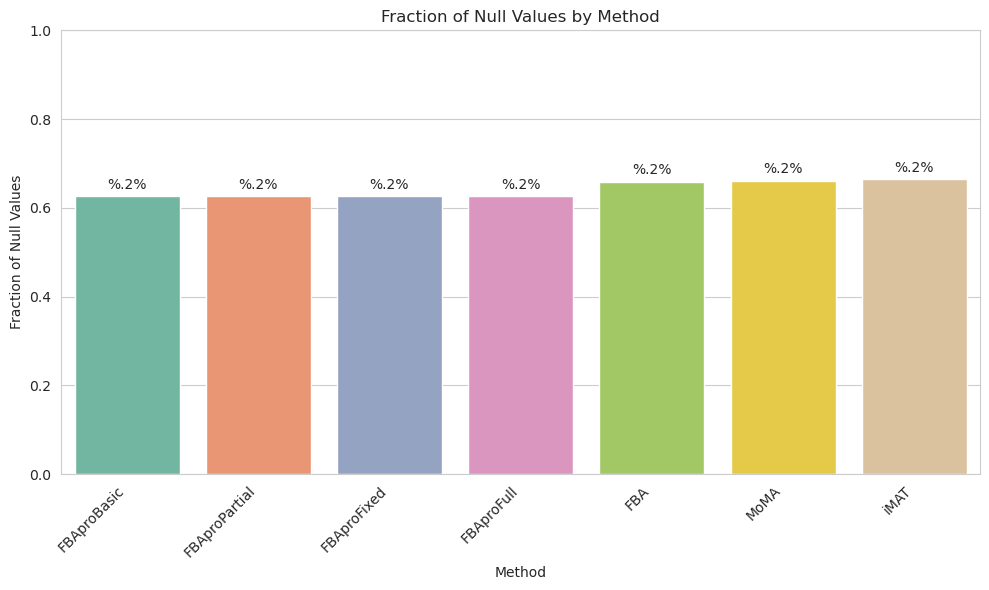

/tmp/ipykernel_3568987/1545563466.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


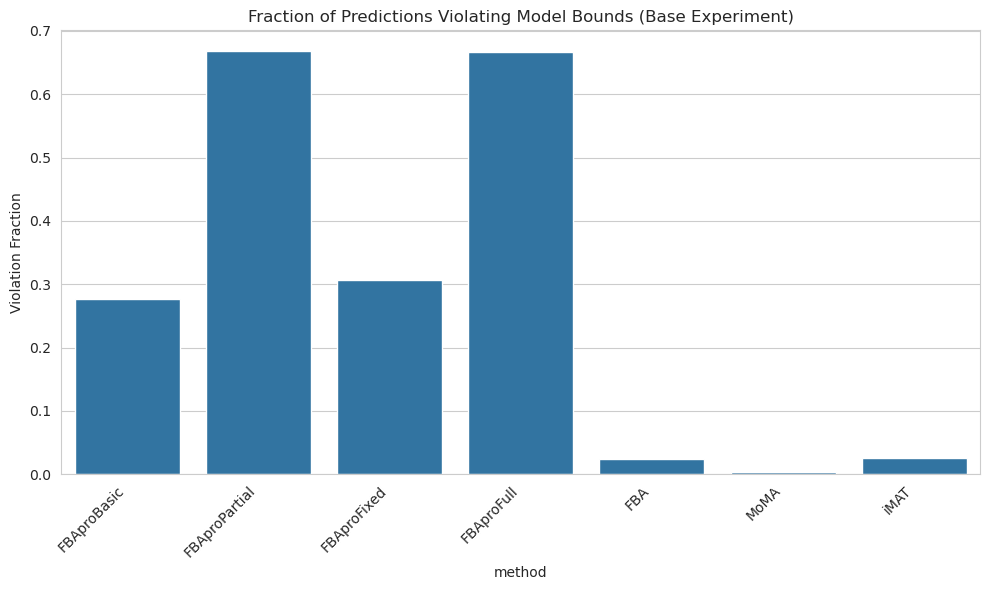

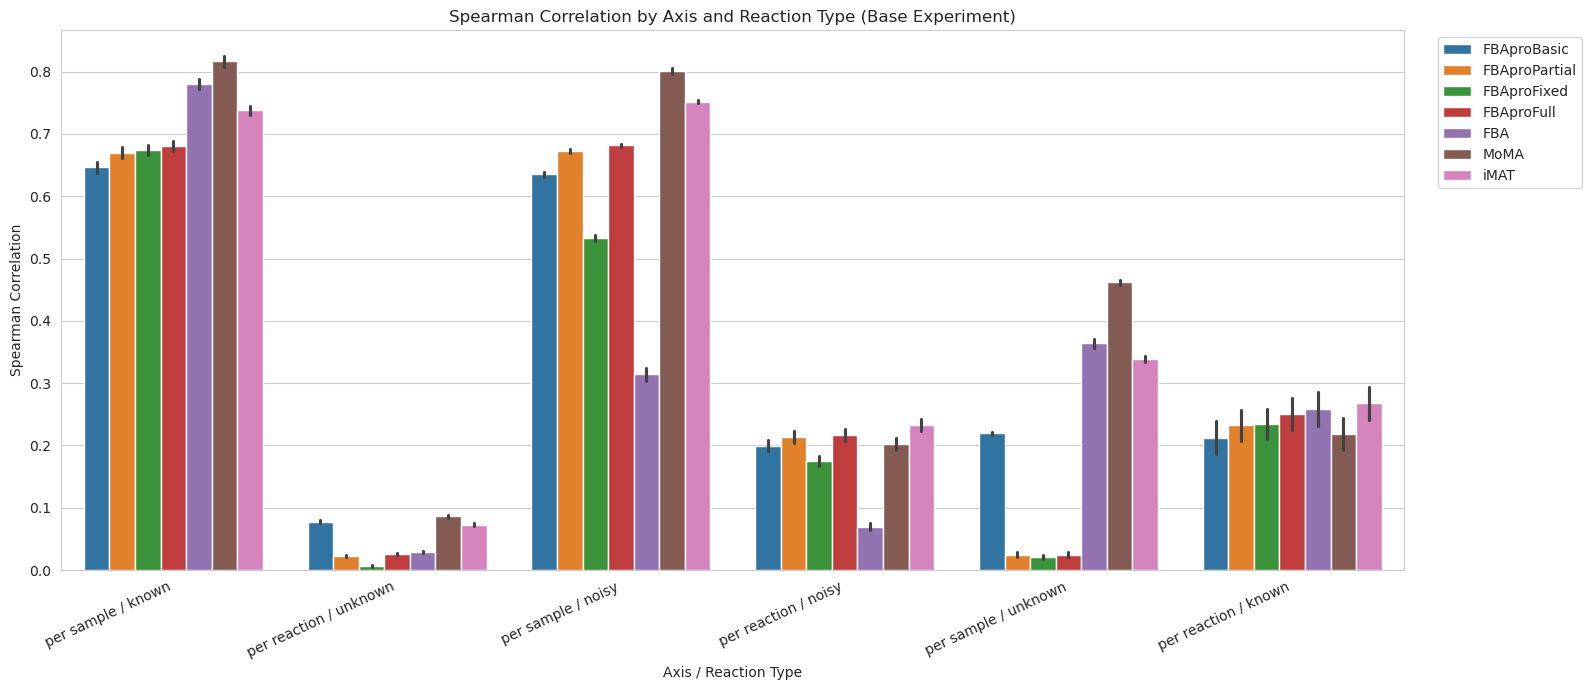

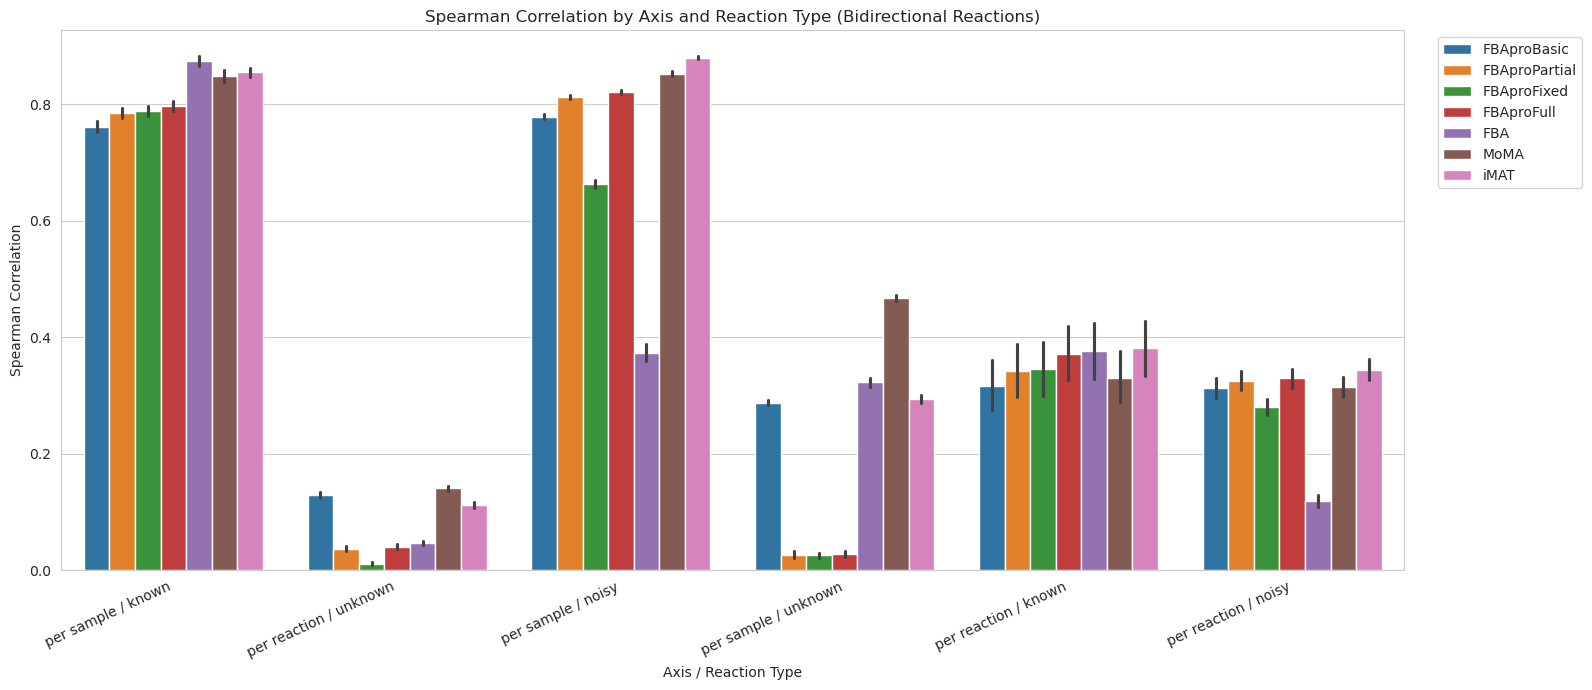

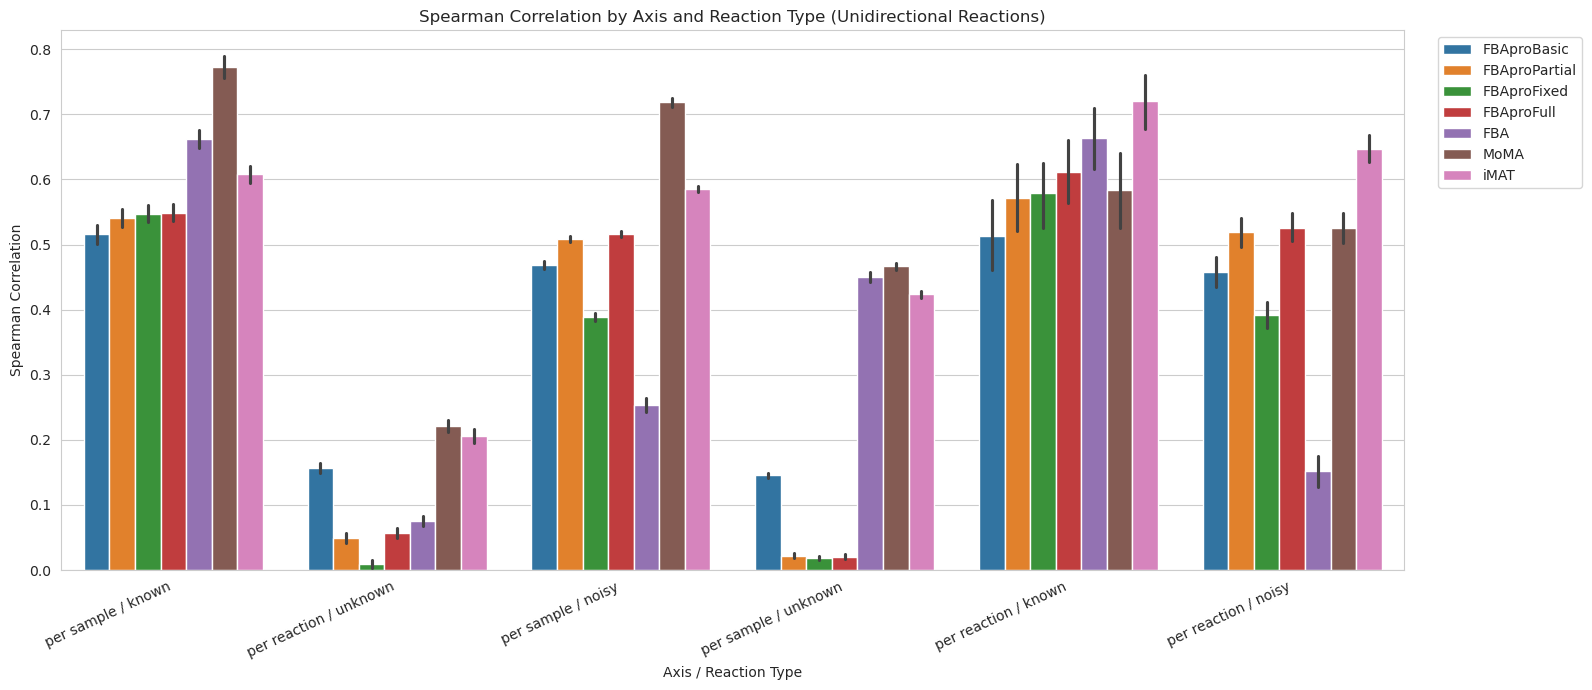

/tmp/ipykernel_3568987/1545563466.py:120: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_3568987/1545563466.py:132: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


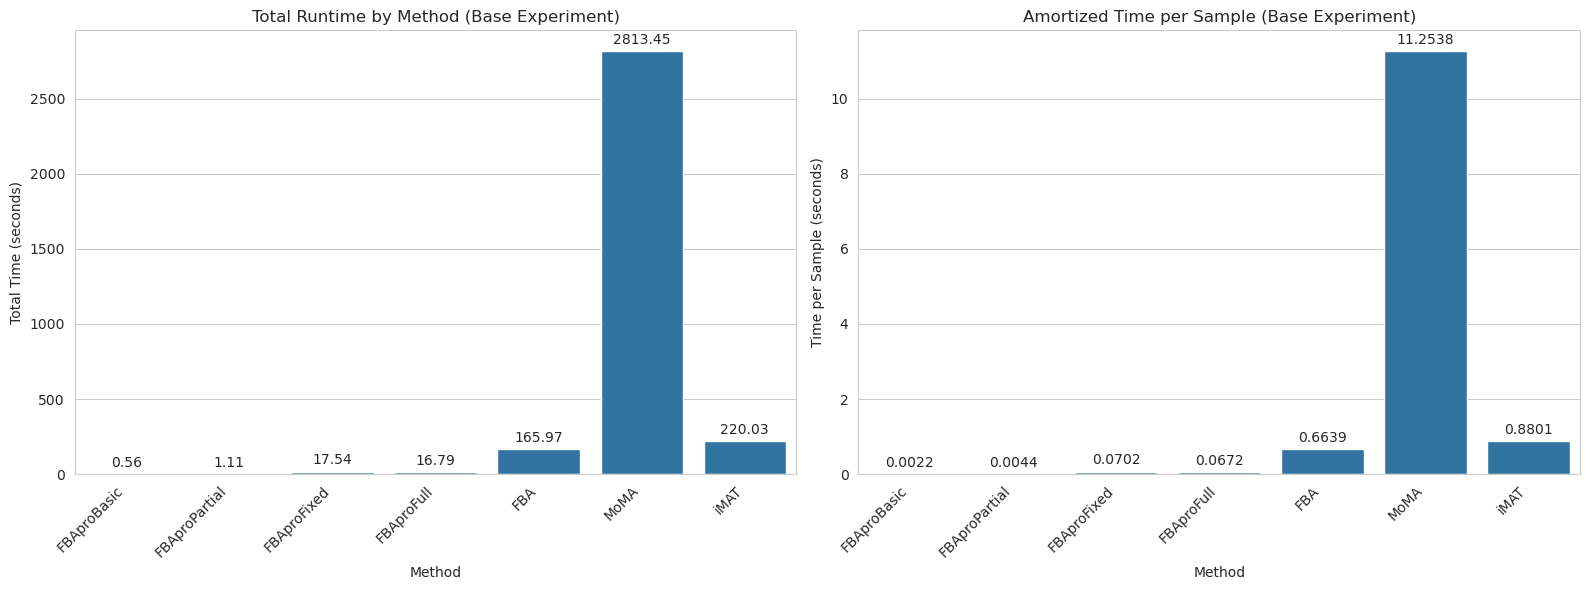


Base experiment complete! Results saved to: synthetic_data_experiment_files/outputs/RECON1_rfba_base_n1.00_k0.020_u0.850_eps1e-5_rs10_ns25


In [11]:
# Generate plots
print("\nGenerating plots...")

# 0. Null fraction
plot_nan_fracs(results_df, " (Base Experiment)", output_dir=output_dir)
results_df['value'] = results_df['value'].fillna(0)
results_bidir_df['value'] = results_bidir_df['value'].fillna(0)
results_df['value'] = results_df['value'].fillna(0)


# 1. Violations
plot_violations(violation_df, title_suffix=" (Base Experiment)", output_dir=output_dir)

# 2. Overall correlations
plot_correlations_by_facet(results_df, title_suffix=" (Base Experiment)",
                          output_dir=output_dir, filename="correlations.png")

# 3. Bidirectional reactions correlations
if len(results_bidir_df) > 0:
    plot_correlations_by_facet(results_bidir_df, title_suffix=" (Bidirectional Reactions)",
                              output_dir=output_dir, filename="correlations_bidirectional.png")

# 4. Unidirectional reactions correlations
if len(results_unidir_df) > 0:
    plot_correlations_by_facet(results_unidir_df, title_suffix=" (Unidirectional Reactions)",
                              output_dir=output_dir, filename="correlations_unidirectional.png")

# 5. Timing results
plot_timing_results(timing_df, title_suffix=" (Base Experiment)", output_dir=output_dir)

print(f"\nBase experiment complete! Results saved to: {output_dir}")

In [12]:
# Noise power sweep

print(f"Running noise-varying experiment...")
print(f"Output directory: {output_dir}")
print(f"Noise steps: {[f'{n:.4f}' for n in noise_power_steps]}")

all_results = []
all_results_bidir = []
all_results_unidir = []

for i, noise_power in enumerate(noise_power_steps):
    print(f"\nStep {i+1}/{len(noise_power_steps)}: noise_power = {noise_power:.4f}")
    
    results_df, results_bidir_df, results_unidir_df, _, _ = run_complete_experiment(
        model, A, ss_basis, objective_reaction_id,
        n_reaction_selections=iterative_n_reaction_samples,
        n_samples_per_selection=iterative_n_samples_per_selection,
        noise_power=noise_power,
        frac_known=base_frac_known_reactions,
        frac_unknown=base_frac_unknown_reactions,
        sampling_method=sampling_method,
        device=device,
        bounds_epsilon=bounds_epsilon,
        bidirectional_indices=bidirectional_indices,
        unidirectional_indices=unidirectional_indices
    )
    
    results_df['noise_power'] = noise_power
    all_results.append(results_df)

    if len(results_bidir_df) > 0:
        results_bidir_df['noise_power'] = noise_power
        all_results_bidir.append(results_bidir_df)

    if len(results_unidir_df) > 0:
        results_unidir_df['noise_power'] = noise_power
        all_results_unidir.append(results_unidir_df)

# Combine all results
noise_combined_df = pd.concat(all_results, ignore_index=True)
noise_combined_df.to_csv(os.path.join(output_dir, 'noise_correlation_results.csv'), index=False)

if all_results_bidir:
    noise_combined_bidir_df = pd.concat(all_results_bidir, ignore_index=True)
    noise_combined_bidir_df.to_csv(os.path.join(output_dir, 'noise_correlation_results_bidirectional.csv'), index=False)

if all_results_unidir:
    noise_combined_unidir_df = pd.concat(all_results_unidir, ignore_index=True)
    noise_combined_unidir_df.to_csv(os.path.join(output_dir, 'noise_correlation_results_unidirectional.csv'), index=False)

Running noise-varying experiment...
Output directory: synthetic_data_experiment_files/outputs/RECON1_rfba_base_n1.00_k0.020_u0.850_eps1e-5_rs10_ns25
Noise steps: ['0.0000', '0.2143', '0.4286', '0.6429', '0.8571', '1.0714', '1.2857', '1.5000', '1.7143', '1.9286', '2.1429', '2.3571', '2.5714', '2.7857', '3.0000']

Step 1/15: noise_power = 0.0000
  Reaction selection 0/5...


/home/abronner/FBApro/projection_methods.py:61: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('stoic', torch.tensor(stoichiometric_matrix, device=device, dtype=dtype),


Input - abs min: 0.00e+00, abs max: 1.00e+06, abs mean: 2.46e+04
output - abs min: 3.44e-15, abs max: 1.12e+06, abs mean: 4.39e+04
S * output - abs min: 0.00e+00, abs max: 1.44e-07, abs mean: 1.25e-09
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 1.00e+06, abs mean: 2.46e+04
output - abs min: 5.63e-15, abs max: 2.48e+06, abs mean: 1.69e+05
S * output - abs min: 5.63e-15, abs max: 2.10e+07, abs mean: 2.19e+05
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 1.00e+06, abs mean: 2.46e+04
output - abs min: 3.33e-14, abs max: 2.28e+18, abs mean: 1.44e+17
S * output - abs min: 0.00e+00, abs max: 1.89e+06, abs mean: 2.49e+04
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 1.00e+06, abs mean: 2.46e+04
output - abs min: 3.60e-15, abs max: 2.55e+17, abs mean: 2.19e+16
S * output - abs min: 0.00e+00, abs max: 6.41e+05, abs mean: 1.05e+04
Suppressing further warnings.
Sample 0
Sample 1
Sample 2
Sample 3
Sample 4
Sample 5
Sample 6
Sample 7
Samp

/home/abronner/.conda/envs/torch_cobra/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/home/abronner/FBApro/projection_methods.py:61: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('stoic', torch.tensor(stoichiometric_matrix, device=device, dtype=dtype),


Input - abs min: 0.00e+00, abs max: 1.00e+06, abs mean: 2.57e+04
output - abs min: 8.53e-14, abs max: 1.31e+06, abs mean: 4.69e+04
S * output - abs min: 0.00e+00, abs max: 3.69e-08, abs mean: 8.73e-10
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 1.00e+06, abs mean: 2.57e+04
output - abs min: 2.69e-13, abs max: 2.88e+06, abs mean: 1.64e+05
S * output - abs min: 8.47e-14, abs max: 1.23e+07, abs mean: 2.09e+05
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 1.00e+06, abs mean: 2.57e+04
output - abs min: 6.62e-14, abs max: 1.12e+18, abs mean: 6.19e+16
S * output - abs min: 0.00e+00, abs max: 3.52e+06, abs mean: 2.25e+04
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 1.00e+06, abs mean: 2.57e+04
output - abs min: 2.19e-14, abs max: 1.61e+17, abs mean: 9.09e+15
S * output - abs min: 0.00e+00, abs max: 7.63e+05, abs mean: 1.21e+04
Suppressing further warnings.
Sample 0
Sample 1
Sample 2
Sample 3
Sample 4
Sample 5
Sample 6
Sample 7
Samp

...

Input - abs min: 0.00e+00, abs max: 4.00e+06, abs mean: 4.16e+04
output - abs min: 3.60e-13, abs max: 3.77e+06, abs mean: 7.95e+04
S * output - abs min: 0.00e+00, abs max: 4.05e-08, abs mean: 1.57e-09
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 4.00e+06, abs mean: 4.16e+04
output - abs min: 5.32e-13, abs max: 5.09e+06, abs mean: 2.96e+05
S * output - abs min: 7.42e-13, abs max: 2.85e+07, abs mean: 3.90e+05
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 4.00e+06, abs mean: 4.16e+04
output - abs min: 1.75e-12, abs max: 3.28e+20, abs mean: 1.23e+19
S * output - abs min: 0.00e+00, abs max: 1.20e+07, abs mean: 1.92e+05
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 4.00e+06, abs mean: 4.16e+04
output - abs min: 3.04e-14, abs max: 2.42e+20, abs mean: 8.23e+18
S * output - abs min: 0.00e+00, abs max: 6.90e+07, abs mean: 1.85e+05
Suppressing further warnings.
Sample 0
Sample 1
Sample 2
Sample 3
Sample 4
Sample 5
Sample 6
Sample 7
Samp

/home/abronner/.conda/envs/torch_cobra/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/home/abronner/FBApro/projection_methods.py:61: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('stoic', torch.tensor(stoichiometric_matrix, device=device, dtype=dtype),


Input - abs min: 0.00e+00, abs max: 3.99e+06, abs mean: 3.62e+04
output - abs min: 2.16e-13, abs max: 3.86e+06, abs mean: 7.22e+04
S * output - abs min: 0.00e+00, abs max: 1.45e-07, abs mean: 1.78e-09
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 3.99e+06, abs mean: 3.62e+04
output - abs min: 6.46e-13, abs max: 5.01e+06, abs mean: 2.63e+05
S * output - abs min: 8.71e-14, abs max: 3.29e+07, abs mean: 3.50e+05
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 3.99e+06, abs mean: 3.62e+04
output - abs min: 1.69e-13, abs max: 3.56e+20, abs mean: 5.19e+18
S * output - abs min: 0.00e+00, abs max: 5.31e+06, abs mean: 8.04e+04
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 3.99e+06, abs mean: 3.62e+04
output - abs min: 1.10e-14, abs max: 3.19e+20, abs mean: 3.27e+18
S * output - abs min: 0.00e+00, abs max: 5.09e+06, abs mean: 6.78e+04
Suppressing further warnings.
Sample 0
Sample 1
Sample 2
Sample 3
Sample 4
Sample 5
Sample 6
Sample 7
Samp

/home/abronner/FBApro/projection_methods.py:61: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('stoic', torch.tensor(stoichiometric_matrix, device=device, dtype=dtype),


Input - abs min: 0.00e+00, abs max: 4.00e+06, abs mean: 4.09e+04
output - abs min: 3.16e-14, abs max: 3.67e+06, abs mean: 7.85e+04
S * output - abs min: 0.00e+00, abs max: 3.85e-07, abs mean: 2.10e-09
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 4.00e+06, abs mean: 4.09e+04
output - abs min: 1.09e-14, abs max: 5.61e+06, abs mean: 3.33e+05
S * output - abs min: 1.09e-14, abs max: 3.82e+07, abs mean: 4.48e+05
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 4.00e+06, abs mean: 4.09e+04
output - abs min: 2.02e-13, abs max: 3.08e+20, abs mean: 1.11e+19
S * output - abs min: 0.00e+00, abs max: 8.08e+06, abs mean: 1.73e+05
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 4.00e+06, abs mean: 4.09e+04
output - abs min: 7.09e-14, abs max: 2.01e+20, abs mean: 7.97e+18
S * output - abs min: 0.00e+00, abs max: 1.22e+07, abs mean: 1.63e+05
Suppressing further warnings.
Sample 0
Sample 1
Sample 2
Sample 3
Sample 4
Sample 5
Sample 6
Sample 7
Samp

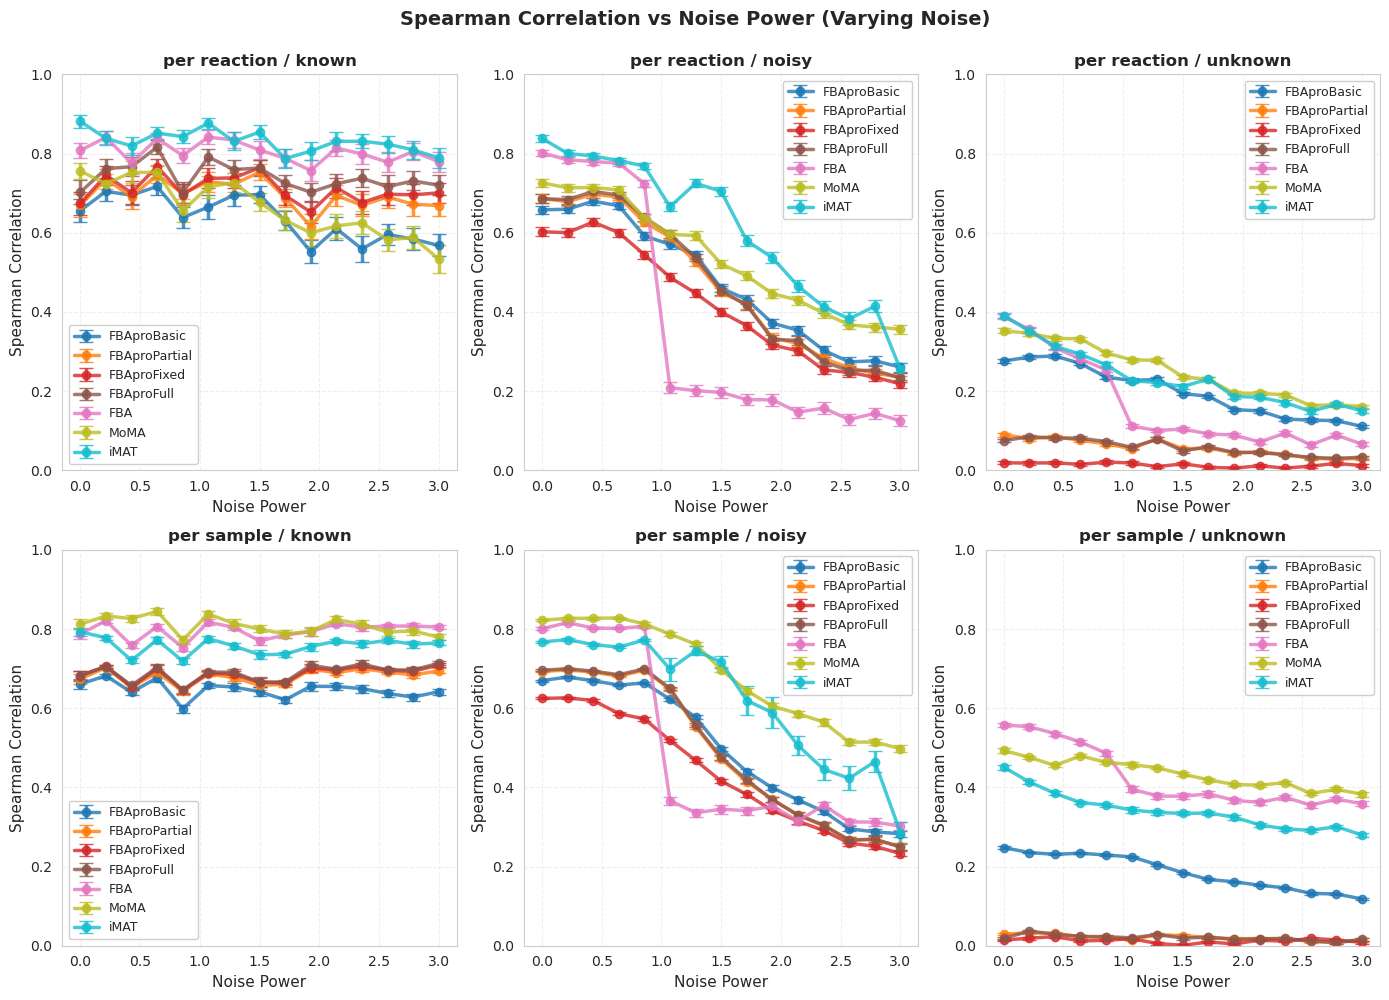

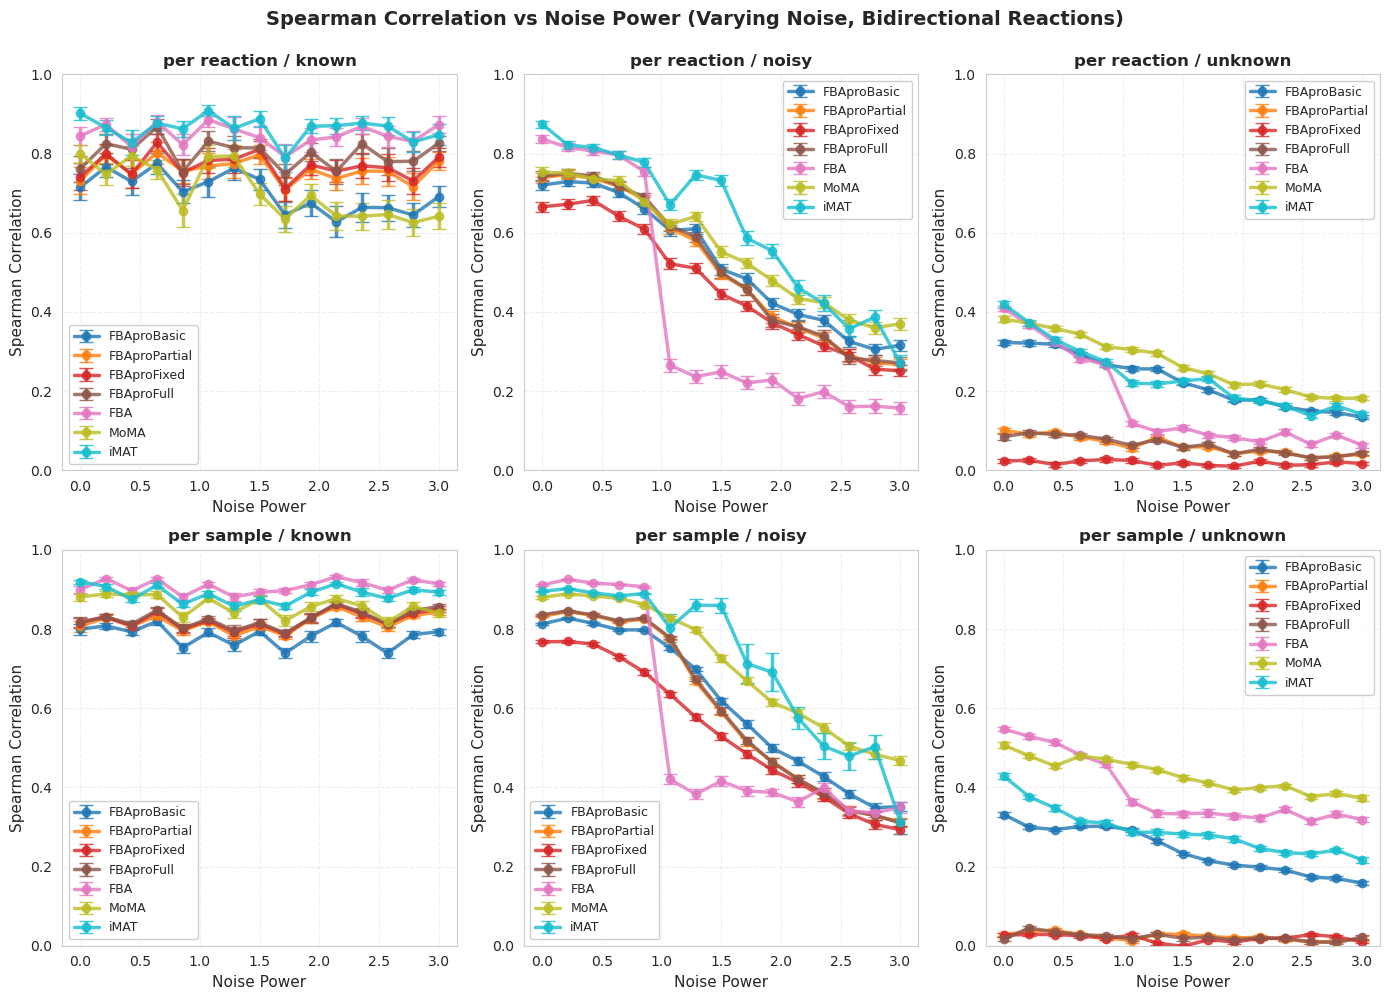

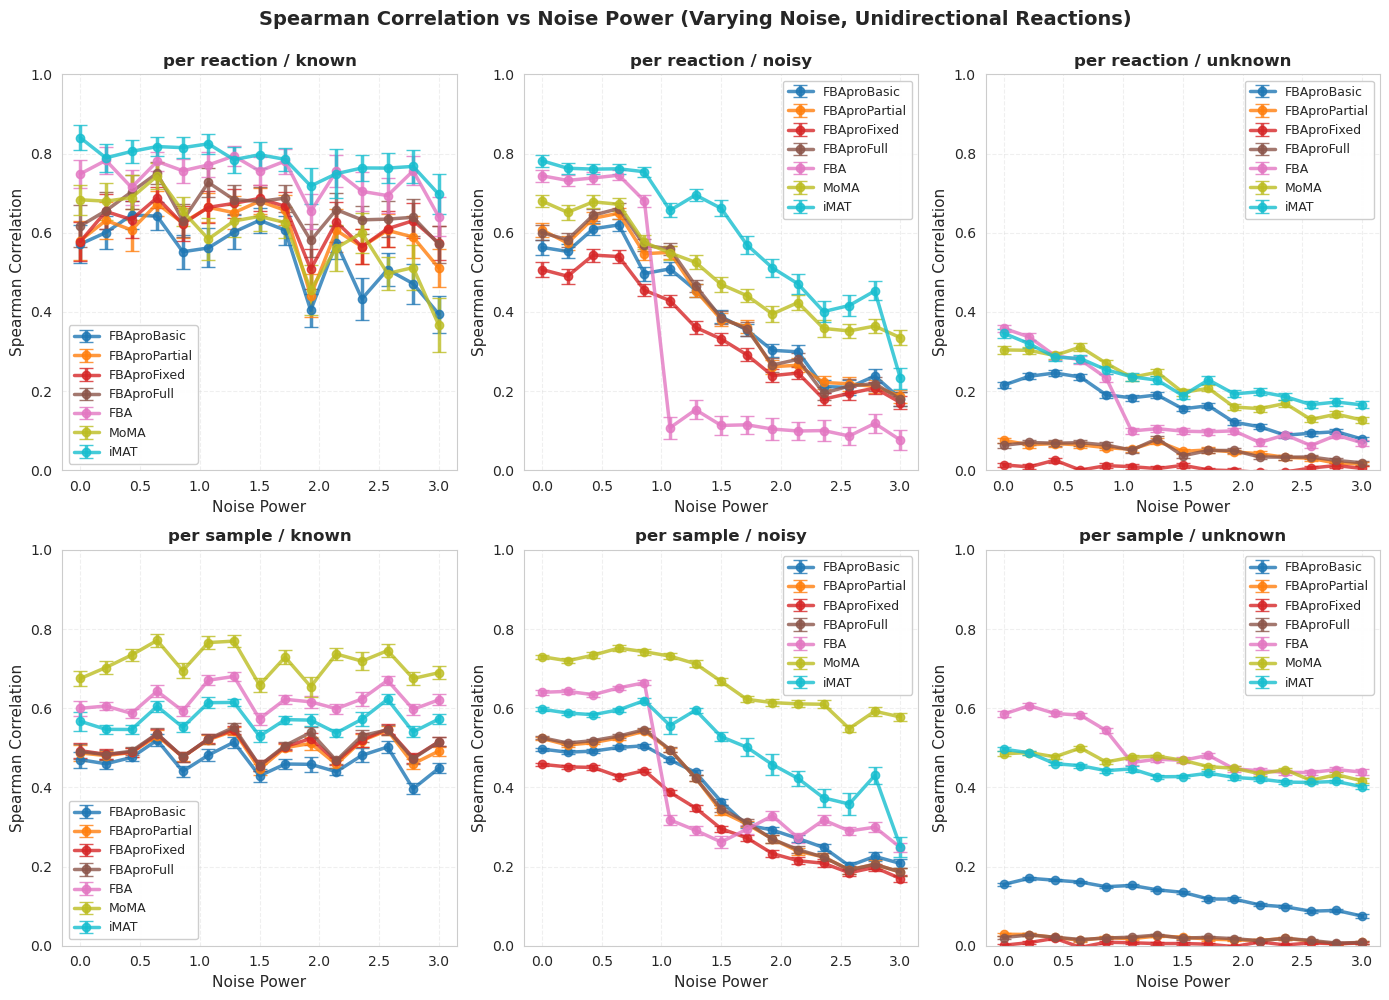


Noise-varying experiment complete! Results saved to: synthetic_data_experiment_files/outputs/RECON1_rfba_base_n1.00_k0.020_u0.850_eps1e-5_rs10_ns25


In [13]:
# Plot
plot_varying_correlations_by_facet(noise_combined_df, "noise_power", "Noise Power", title_suffix=" (Varying Noise)",
                          output_dir=output_dir, filename="noise_correlations.png", log_scale=False)

if all_results_bidir:
    plot_varying_correlations_by_facet(noise_combined_bidir_df, "noise_power", "Noise Power", title_suffix=" (Varying Noise, Bidirectional Reactions)",
                              output_dir=output_dir, filename="noise_correlations_bidirectional.png", log_scale=False)

if all_results_unidir:
    plot_varying_correlations_by_facet(noise_combined_unidir_df, "noise_power", "Noise Power", title_suffix=" (Varying Noise, Unidirectional Reactions)",
                              output_dir=output_dir, filename="noise_correlations_unidirectional.png", log_scale=False)

print(f"\nNoise-varying experiment complete! Results saved to: {output_dir}")

In [14]:
noise_combined_df

,method,metric,axis,masking,value,selection_idx,noise_power
0,FBAproBasic,spearmanr,per sample,known,0.744453,0,0.0
1,FBAproBasic,spearmanr,per sample,known,0.684284,0,0.0
2,FBAproBasic,spearmanr,per sample,known,0.741869,0,0.0
3,FBAproBasic,spearmanr,per sample,known,0.773561,0,0.0
4,FBAproBasic,spearmanr,per sample,known,0.730453,0,0.0
...,...,...,...,...,...,...,...
1987645,MoMA,spearmanr,per reaction,noisy,NaN,4,3.0
1987646,MoMA,spearmanr,per reaction,noisy,NaN,4,3.0
1987647,MoMA,spearmanr,per reaction,noisy,NaN,4,3.0
1987648,MoMA,spearmanr,per reaction,noisy,NaN,4,3.0


In [15]:
for group, dat in noise_combined_df.groupby(['method']):
    print(group, dat['value'].isna().mean())

('FBAproBasic',) 0.6610389153019898
('FBAproPartial',) 0.6610389153019898
('FBAproFixed',) 0.6610389153019898
('FBAproFull',) 0.6610389153019898
('FBA',) 0.70211656981863
('MoMA',) 0.6957668603627399
('iMAT',) 0.703166050360979


/tmp/ipykernel_3568987/3981212660.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, dat in noise_combined_df.groupby(['method']):


## Varying Known Fraction Experiment

In [ ]:
# Known fraction sweep

print(f"Running known-fraction-varying experiment...")
print(f"Output directory: {output_dir}")
print(f"Known fraction steps: {[f'{k:.4f}' for k in frac_known_steps]}")

all_results = []
all_results_bidir = []
all_results_unidir = []

for i, frac_known in enumerate(frac_known_steps):
    print(f"\nStep {i+1}/{len(frac_known_steps)}: frac_known = {frac_known:.4f}")
    
    # Adjust unknown fraction to avoid overlap
    frac_unknown_adj = min(base_frac_unknown_reactions, 1.0 - frac_known)
    
    results_df, results_bidir_df, results_unidir_df, _, _ = run_complete_experiment(
        model, A, ss_basis, objective_reaction_id,
        n_reaction_selections=iterative_n_reaction_samples,
        n_samples_per_selection=iterative_n_samples_per_selection,
        noise_power=base_noise_power,
        frac_known=frac_known,
        frac_unknown=frac_unknown_adj,
        sampling_method=sampling_method,
        device=device,
        bounds_epsilon=bounds_epsilon,
        bidirectional_indices=bidirectional_indices,
        unidirectional_indices=unidirectional_indices
    )
    
    results_df['frac_known'] = frac_known
    all_results.append(results_df)

    if len(results_bidir_df) > 0:
        results_bidir_df['frac_known'] = frac_known
        all_results_bidir.append(results_bidir_df)

    if len(results_unidir_df) > 0:
        results_unidir_df['frac_known'] = frac_known
        all_results_unidir.append(results_unidir_df)

# Combine all results
known_combined_df = pd.concat(all_results, ignore_index=True)
known_combined_df.to_csv(os.path.join(output_dir, 'known_correlation_results.csv'), index=False)

if all_results_bidir:
    known_combined_bidir_df = pd.concat(all_results_bidir, ignore_index=True)
    known_combined_bidir_df.to_csv(os.path.join(output_dir, 'known_correlation_results_bidirectional.csv'), index=False)

if all_results_unidir:
    known_combined_unidir_df = pd.concat(all_results_unidir, ignore_index=True)
    known_combined_unidir_df.to_csv(os.path.join(output_dir, 'known_correlation_results_unidirectional.csv'), index=False)

Running known-fraction-varying experiment...
Output directory: synthetic_data_experiment_files/outputs/RECON1_rfba_base_n1.00_k0.020_u0.850_eps1e-5_rs10_ns25
Known fraction steps: ['0.0100', '0.0138', '0.0190', '0.0262', '0.0362', '0.0499', '0.0688', '0.0949', '0.1308', '0.1804', '0.2488', '0.3431', '0.4732', '0.6526', '0.9000']

Step 1/15: frac_known = 0.0100
  Reaction selection 0/5...


/home/abronner/FBApro/projection_methods.py:61: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('stoic', torch.tensor(stoichiometric_matrix, device=device, dtype=dtype),


Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.30e+04
output - abs min: 1.92e-14, abs max: 1.93e+06, abs mean: 4.45e+04
S * output - abs min: 0.00e+00, abs max: 1.93e-07, abs mean: 1.10e-09
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.30e+04
output - abs min: 1.27e-12, abs max: 3.06e+06, abs mean: 1.88e+05
S * output - abs min: 3.05e-14, abs max: 2.33e+07, abs mean: 2.49e+05
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.30e+04
output - abs min: 9.85e-14, abs max: 6.80e+19, abs mean: 3.97e+18
S * output - abs min: 0.00e+00, abs max: 4.71e+06, abs mean: 6.32e+04
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.30e+04
output - abs min: 1.54e-13, abs max: 4.43e+19, abs mean: 2.31e+18
S * output - abs min: 0.00e+00, abs max: 5.62e+06, abs mean: 5.12e+04
Suppressing further warnings.
Sample 0
Sample 1
Sample 2
Sample 3
Sample 4
Sample 5
Sample 6
Sample 7
Samp

/home/abronner/.conda/envs/torch_cobra/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
/home/abronner/FBApro/projection_methods.py:61: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('stoic', torch.tensor(stoichiometric_matrix, device=device, dtype=dtype),


Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.25e+04
output - abs min: 2.00e-13, abs max: 1.91e+06, abs mean: 4.44e+04
S * output - abs min: 0.00e+00, abs max: 1.58e-07, abs mean: 1.07e-09
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.25e+04
output - abs min: 2.21e-13, abs max: 2.96e+06, abs mean: 1.74e+05
S * output - abs min: 2.21e-13, abs max: 1.32e+07, abs mean: 2.21e+05
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.25e+04
output - abs min: 1.04e-13, abs max: 6.58e+19, abs mean: 3.18e+18
S * output - abs min: 0.00e+00, abs max: 3.76e+06, abs mean: 5.34e+04
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.25e+04
output - abs min: 6.26e-14, abs max: 3.56e+19, abs mean: 1.69e+18
S * output - abs min: 0.00e+00, abs max: 3.42e+06, abs mean: 3.86e+04
Suppressing further warnings.
Sample 0
Sample 1
Sample 2
Sample 3
Sample 4
Sample 5
Sample 6
Sample 7
Samp

...

Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.89e+04
output - abs min: 5.56e-13, abs max: 1.80e+06, abs mean: 5.41e+04
S * output - abs min: 0.00e+00, abs max: 1.53e-07, abs mean: 1.19e-09
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.89e+04
output - abs min: 3.11e-13, abs max: 2.89e+06, abs mean: 1.98e+05
S * output - abs min: 1.22e-12, abs max: 1.32e+07, abs mean: 2.60e+05
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.89e+04
output - abs min: 2.20e-13, abs max: 1.06e+20, abs mean: 4.41e+18
S * output - abs min: 0.00e+00, abs max: 9.07e+06, abs mean: 6.94e+04
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.89e+04
output - abs min: 3.10e-14, abs max: 6.89e+19, abs mean: 2.63e+18
S * output - abs min: 0.00e+00, abs max: 2.67e+06, abs mean: 5.40e+04
Suppressing further warnings.
Sample 0
Sample 1
Sample 2
Sample 3
Sample 4
Sample 5
Sample 6
Sample 7
Samp

/home/abronner/FBApro/projection_methods.py:61: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('stoic', torch.tensor(stoichiometric_matrix, device=device, dtype=dtype),


Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.76e+04
output - abs min: 8.77e-14, abs max: 2.01e+06, abs mean: 5.28e+04
S * output - abs min: 0.00e+00, abs max: 3.09e-08, abs mean: 1.09e-09
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.76e+04
output - abs min: 1.81e-13, abs max: 2.53e+06, abs mean: 1.75e+05
S * output - abs min: 3.20e-13, abs max: 1.61e+07, abs mean: 2.31e+05
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.76e+04
output - abs min: 1.31e-14, abs max: 9.66e+19, abs mean: 4.77e+18
S * output - abs min: 0.00e+00, abs max: 8.40e+06, abs mean: 7.74e+04
Suppressing further warnings.
Input - abs min: 0.00e+00, abs max: 2.00e+06, abs mean: 2.76e+04
output - abs min: 8.54e-14, abs max: 6.90e+19, abs mean: 2.58e+18
S * output - abs min: 0.00e+00, abs max: 3.86e+06, abs mean: 5.55e+04
Suppressing further warnings.
Sample 0
Sample 1
Sample 2
Sample 3
Sample 4
Sample 5
Sample 6
Sample 7
Samp

/home/abronner/.conda/envs/torch_cobra/lib/python3.11/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)



Step 3/15: frac_known = 0.0190
  Reaction selection 0/5...


In [ ]:
# Plot
plot_varying_correlations_by_facet(known_combined_df, "frac_known", "Fraction of Known Reactions", title_suffix=" (Varying Known Fraction)",
                          output_dir=output_dir, filename="known_correlations.png")

if all_results_bidir:
    plot_varying_correlations_by_facet(known_combined_bidir_df, "frac_known", "Fraction of Known Reactions", title_suffix=" (Varying Known Fraction, Bidirectional Reactions)",
                              output_dir=output_dir, filename="known_correlations_bidirectional.png")

if all_results_unidir:
    plot_varying_correlations_by_facet(known_combined_unidir_df, "frac_known", "Fraction of Known Reactions", title_suffix=" (Varying Known Fraction, Unidirectional Reactions)",
                              output_dir=output_dir, filename="known_correlations_unidirectional.png")

print(f"\nKnown fraction varying experiment complete! Results saved to: {output_dir}")

## Varying Unknown Fraction Experiment

In [ ]:
# Unknown fraction sweep

print(f"Running unknown-fraction-varying experiment...")
print(f"Output directory: {output_dir}")
print(f"Unknown fraction steps: {[f'{u:.4f}' for u in frac_unknown_steps]}")

all_results = []
all_results_bidir = []
all_results_unidir = []

for i, frac_unknown in enumerate(frac_unknown_steps):
    print(f"\nStep {i+1}/{len(frac_unknown_steps)}: frac_unknown = {frac_unknown:.4f}")
    
    # Adjust known fraction to avoid overlap
    frac_known_adj = min(base_frac_known_reactions, 1.0 - frac_unknown)
    
    results_df, results_bidir_df, results_unidir_df, _, _ = run_complete_experiment(
        model, A, ss_basis, objective_reaction_id,
        n_reaction_selections=iterative_n_reaction_samples,
        n_samples_per_selection=iterative_n_samples_per_selection,
        noise_power=base_noise_power,
        frac_known=frac_known_adj,
        frac_unknown=frac_unknown,
        sampling_method=sampling_method,
        device=device,
        bounds_epsilon=bounds_epsilon,
        bidirectional_indices=bidirectional_indices,
        unidirectional_indices=unidirectional_indices
    )
    
    results_df['frac_unknown'] = frac_unknown
    all_results.append(results_df)

    if len(results_bidir_df) > 0:
        results_bidir_df['frac_unknown'] = frac_unknown
        all_results_bidir.append(results_bidir_df)

    if len(results_unidir_df) > 0:
        results_unidir_df['frac_unknown'] = frac_unknown
        all_results_unidir.append(results_unidir_df)

# Combine all results
unknown_combined_df = pd.concat(all_results, ignore_index=True)
unknown_combined_df.to_csv(os.path.join(output_dir, 'unknown_correlation_results.csv'), index=False)

if all_results_bidir:
    unknown_combined_bidir_df = pd.concat(all_results_bidir, ignore_index=True)
    unknown_combined_bidir_df.to_csv(os.path.join(output_dir, 'unknown_correlation_results_bidirectional.csv'), index=False)

if all_results_unidir:
    unknown_combined_unidir_df = pd.concat(all_results_unidir, ignore_index=True)
    unknown_combined_unidir_df.to_csv(os.path.join(output_dir, 'unknown_correlation_results_unidirectional.csv'), index=False)

In [ ]:
# Plot
plot_varying_correlations_by_facet(unknown_combined_df, "frac_unknown", "Fraction of Unknown Reactions", title_suffix=" (Varying Unknown Fraction)",
                          output_dir=output_dir, filename="unknown_correlations.png")

if all_results_bidir:
    plot_varying_correlations_by_facet(unknown_combined_bidir_df, "frac_unknown", "Fraction of Unknown Reactions", title_suffix=" (Varying Unknown Fraction, Bidirectional Reactions)",
                              output_dir=output_dir, filename="unknown_correlations_bidirectional.png")

if all_results_unidir:
    plot_varying_correlations_by_facet(unknown_combined_unidir_df, "frac_unknown", "Fraction of Unknown Reactions", title_suffix=" (Varying Unknown Fraction, Unidirectional Reactions)",
                              output_dir=output_dir, filename="unknown_correlations_unidirectional.png")

print(f"\nUnknown fraction varying experiment complete! Results saved to: {output_dir}")